# Watching the Kirkwood Gaps Form

#### This tutorial starts from a smooth, gap-free asteroid belt, lets Jupiter and Saturn act on it for a hundred million years, and animates the gaps opening — then compares the result with the real belt from MPC data.

The [Kirkwood gaps tutorial](https://docs.minorplanetcenter.net/tutorials/notebooks/mpc_tutorial_orbit_kirkwood/) showed *where* the gaps are: sharp deficits in the distribution of semi-major axes at the 4:1, 3:1, 5:2, 7:3 and 2:1 mean-motion resonances with Jupiter. This one is about *how they got there*. The mechanism was found by [Wisdom (1983)](https://ui.adsabs.harvard.edu/abs/1983Icar...56...51W): an asteroid in one of these resonances does not sit still. Its eccentricity wanders chaotically, and every so often it jumps high enough that the orbit crosses Mars's or Earth's — after which a close encounter with a planet removes the asteroid from the belt for good. The resonance does not clear a lane in semi-major axis; it pumps eccentricity until the inner planets do the clearing.

That is a story about *time*, so it wants an animation. We:

1. take the real belt's semi-major-axis distribution from `MPCORB.DAT` as the answer we are trying to reproduce;
2. build a **synthetic belt** of test particles with no gaps at all, spread uniformly between 2.0 and 3.5 AU on nearly circular orbits;
3. integrate them with **REBOUND**'s symplectic `WHFast` integrator under the Sun, Jupiter and Saturn for a hundred million years, in three phases with checkpoints — splitting the particles across CPU cores, which is legitimate because test particles do not interact;
4. **mark particles as removed** once their orbits cross Mars's, standing in for the planetary encounter that would eject them, and freeze them in the plots at the point where they crossed;
5. **animate** the belt in the (semi-major axis, eccentricity) plane alongside its evolving histogram, with the real belt underneath for comparison and a clock that speeds up tenfold at each phase, and render it as video for the web.

The result is a hierarchy of timescales spanning three orders of magnitude: the 3:1 and 5:2 gaps open within the first million years, the inner edge is eaten away by the ν₆ secular resonance on the same timescale, the 7:3 gap takes ten million years to get going, and the 2:1 does nothing at all for three million years before emptying steadily over the following tens of millions — nine tenths of its core is gone by a hundred million years, by which time the belt's outer edge has begun to form as well. Understanding that hierarchy took the field another decade after Wisdom's paper.

This notebook builds on the [Kirkwood gaps](https://docs.minorplanetcenter.net/tutorials/notebooks/mpc_tutorial_orbit_kirkwood/) and [N-body simulation](https://docs.minorplanetcenter.net/tutorials/notebooks/mpc_tutorial_orbit_to_rebound/) tutorials in the [Working with Orbits](https://docs.minorplanetcenter.net/tutorials/orbit_tutorials/) section, and on the animation techniques of the [minimoon animation tutorial](https://docs.minorplanetcenter.net/tutorials/notebooks/mpc_tutorial_orbit_animation_minimoons/).

## Environment Setup

This notebook requires `rebound`, `matplotlib`, `numpy`, and `requests`, plus the `ffmpeg` command-line tool to write MP4 files. We recommend creating a dedicated conda environment and registering it as a Jupyter kernel so that all dependencies are isolated and reproducible.

Run the following commands once in a terminal before opening this notebook:

```bash
# Create and populate the environment
conda create -n orbit-tutorial python=3.11 -y
conda activate orbit-tutorial
pip install rebound mpc-orb astropy matplotlib numpy requests ipykernel
conda install -c conda-forge ffmpeg          # for MP4 output (GIFs need only Pillow, which matplotlib brings in)

# Register the environment as a Jupyter kernel
python -m ipykernel install --user --name orbit-tutorial --display-name "Python (orbit-tutorial)"
```

If you do not already have a way of running Jupyter notebooks, also install Jupyter itself (`pip install jupyter`), then launch it from the directory containing this notebook with:

```bash
jupyter notebook
```

and open this file in the browser tab that appears. However you run the notebook, select **Kernel > Change Kernel > Python (orbit-tutorial)** before running the cells below.

If you already created the `orbit-tutorial` environment for the companion tutorials, you can simply reuse it.

**Runtime note:** Step 3 integrates four thousand test particles for a hundred million years, in three phases. On a laptop with eight cores the first phase (1 Myr) takes about five minutes, the second (to 10 Myr) about three quarters of an hour, and the third (to 100 Myr) about six hours — an overnight run. Every phase is cached to disk and checkpointed, so an interrupted run resumes where it stopped, and slicing `PHASES` in Step 2 lets you stop after phase 1 or 2, which already show the 3:1 and 5:2 gaps opening. Step 3b, which checks the time step, adds another twenty minutes the first time it is run.

# Install and Import Packages

In [1]:
import os
import gzip
import time
import base64
import collections
import multiprocessing
import warnings
from pathlib import Path

import requests
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter, PillowWriter
from IPython.display import HTML

import rebound

# dark plot style, shared by every figure below
plt.rcParams.update({"figure.facecolor": "black", "axes.facecolor": "black", "savefig.facecolor": "black",
                     "text.color": "white", "axes.labelcolor": "white", "xtick.color": "#bbbbbb",
                     "ytick.color": "#bbbbbb", "axes.edgecolor": "#888888", "font.size": 11})
BLUE, ORANGE, GREY = "#3f89c4", "#e07b39", "#777777"

# Step 1: The Real Belt, from MPCORB

The target: the semi-major-axis distribution of the known asteroids. We download and parse [`MPCORB.DAT`](https://minorplanetcenter.net/iau/MPCORB.html) exactly as in the Kirkwood tutorial (only the semi-major axis and the epoch code are needed here), keep the orbits at the common epoch, and histogram them. Jupiter's semi-major axis, which sets the resonance locations through Kepler's third law, comes from the same REBOUND/Horizons query we will use for the simulation.

**Download note:** the cell caches `MPCORB.DAT.gz` (about 90 MB) in the notebook's working directory and only downloads it if it is not already present.

In [2]:
MPCORB_URL = "https://www.minorplanetcenter.net/iau/MPCORB/MPCORB.DAT.gz"
MPCORB_FILE = "MPCORB.DAT.gz"

if not os.path.exists(MPCORB_FILE):
    print(f"Downloading {MPCORB_URL} (about 90 MB; this may take a few minutes)")
    with requests.get(MPCORB_URL, stream=True, timeout=600) as r:
        r.raise_for_status()
        with open(MPCORB_FILE + ".part", "wb") as f:
            for chunk in r.iter_content(chunk_size=1024 * 1024):
                f.write(chunk)
    os.rename(MPCORB_FILE + ".part", MPCORB_FILE)
    print("  done")
else:
    print(f"Using cached {MPCORB_FILE}")

# Fixed-width columns (1-indexed): epoch 21-25 (packed), e 71-79, a 93-103
rows = []
with gzip.open(MPCORB_FILE, "rt") as f:
    in_header = True
    for line in f:
        if in_header:
            if line.startswith("----------"):
                in_header = False
            continue
        if len(line) < 104:
            continue
        try:
            rows.append((float(line[92:103]), float(line[70:79]), line[20:25]))
        except ValueError:
            continue
epoch_mode = collections.Counter(r[2] for r in rows).most_common(1)[0][0]
real = np.array([(a, e) for a, e, ep in rows if ep == epoch_mode and 1.5 < a < 4.5 and e < 1])
a_real, e_real = real[:, 0], real[:, 1]
print(f"{len(a_real):,} real orbits with 1.5 < a < 4.5 AU at the common epoch {epoch_mode!r}")

# Sun, Jupiter and Saturn from JPL Horizons at the catalogue epoch; this is also the simulation's planetary system
def unpack_epoch(packed):
    century = {"I": 18, "J": 19, "K": 20}[packed[0]]
    year = century * 100 + int(packed[1:3])
    month = int(packed[3], 36) if packed[3].isdigit() else ord(packed[3]) - 55
    day = int(packed[4], 36) if packed[4].isdigit() else ord(packed[4]) - 55
    return f"{year:04d}-{month:02d}-{day:02d}"

epoch_date = unpack_epoch(epoch_mode)
planets_sim = rebound.Simulation()
planets_sim.units = ("AU", "yr", "Msun")
for body in ["Sun", "Jupiter", "Saturn"]:
    planets_sim.add(body, date=f"{epoch_date} 00:00")
a_jup = planets_sim.particles[1].orbit(primary=planets_sim.particles[0]).a
RESONANCES = {"4:1": 4, "3:1": 3, "5:2": 2.5, "7:3": 7 / 3, "2:1": 2}
a_res = {name: a_jup * ratio ** (-2 / 3) for name, ratio in RESONANCES.items()}
print(f"Jupiter: a = {a_jup:.3f} AU; resonances at " + ", ".join(f"{k} {v:.2f}" for k, v in a_res.items()))

Using cached MPCORB.DAT.gz


1,511,155 real orbits with 1.5 < a < 4.5 AU at the common epoch 'K2669'
Searching NASA Horizons for 'Sun'... 


Found: Sun (10) 
Searching NASA Horizons for 'Jupiter'... 


Found: Jupiter Barycenter (5) (chosen from query 'Jupiter')
Searching NASA Horizons for 'Saturn'... 


Found: Saturn Barycenter (6) (chosen from query 'Saturn')
Jupiter: a = 5.203 AU; resonances at 4:1 2.06, 3:1 2.50, 5:2 2.82, 7:3 2.96, 2:1 3.28


# Step 2: A Synthetic Belt with No Gaps

Now the initial conditions for the experiment: `N_PARTICLES` massless test particles spread **uniformly** in semi-major axis from 2.0 to 3.5 AU, with small eccentricities (0–0.15) and inclinations (0–10°) and random orbital angles. Nothing about this distribution knows where the resonances are; any structure that appears later is Jupiter's doing.

A few parameters control the cost of the experiment. The `PHASES` table sets the integration span and the snapshot cadence in each phase — the cadence grows tenfold per phase, so the animation spends its frames where the belt is changing fastest; the time step `DT` must be a small fraction of the shortest orbital period (about 2.8 years at 2 AU) — Step 3b shows how large it can safely be; and `N_PROC` is the number of CPU cores to spread the particles over.

In [3]:
N_PARTICLES = 4000            # test particles in the synthetic belt
A_MIN, A_MAX = 2.0, 3.5       # AU
E_MAX, I_MAX_DEG = 0.15, 10.0
DT = 0.2                      # WHFast time step in years (~14 steps per orbit at 2 AU); validated against 0.08 in Step 3b
Q_MARS = 1.67                 # AU: Mars's aphelion distance; a particle with perihelion inside it is removed
N_PROC = max(1, min(8, (os.cpu_count() or 2) - 2))
BINS = np.arange(1.9, 3.6, 0.02)                      # histogram bins in a, 0.02 AU wide

# Three phases with a snapshot cadence that grows tenfold each time: fine where things happen fast,
# coarse where they happen slowly.        (phase, t_start [yr], t_end [yr], snapshot every [yr])
PHASES = [(1, 0.0,    1.0e6, 2.0e3),
          (2, 1.0e6,  1.0e7, 2.0e4),
          (3, 1.0e7,  1.0e8, 2.0e5)]
CKPT_DIR = "kirkwood_gaps_ckpt"                       # per-process REBOUND checkpoints between phases

# The planetary system, as plain numbers so that it can be handed to worker processes
PLANETS = [(p.m, p.x, p.y, p.z, p.vx, p.vy, p.vz) for p in planets_sim.particles]
n_snap = sum(len(np.arange(t0 if ph == 1 else t0 + cad, t1 + 1e-6, cad)) for ph, t0, t1, cad in PHASES)
print(f"{N_PARTICLES} particles, {PHASES[-1][2]/1e6:.0f} Myr in {len(PHASES)} phases, {n_snap} snapshots, {N_PROC} processes")

4000 particles, 100 Myr in 3 phases, 1401 snapshots, 8 processes


# Step 3: Integrate with WHFast, in Parallel

`WHFast` ([Rein & Tamayo 2015](https://ui.adsabs.harvard.edu/abs/2015MNRAS.452..376R)) is REBOUND's symplectic Wisdom–Holman integrator: fast, and with the long-term energy behaviour that a hundred-million-year run needs. Three details of its use here:

- **Test particles.** Setting `sim.N_active = 3` tells REBOUND that only the Sun, Jupiter and Saturn have mass; the belt particles feel them but not each other, so the cost grows linearly with the number of particles rather than quadratically.
- **`safe_mode = 0`.** By default WHFast converts between coordinate systems every step so that positions are always readable; switching that off roughly doubles the speed, at the price of calling `sim.synchronize()` before reading positions at each snapshot.
- **Vectorized elements.** Calling `particle.orbit()` two thousand times per snapshot is slow in Python; the semi-major axis and eccentricity follow from the heliocentric position and velocity in a few lines of `numpy` (the vis-viva equation for `a`, the angular momentum for `e`).

Because the particles are independent, `run_chunk` integrates any subset of them, and `run_parallel` spreads `N_PARTICLES` over `N_PROC` worker processes with `multiprocessing`. The workers are started with the `fork` method, which lets them see the functions defined in this notebook (it is the default on Linux and works on macOS; on Windows the cell falls back to running the chunks one after another).

Two more things happen inside `run_chunk`, both in the service of a long run:

- **Removal.** At every snapshot a particle whose perihelion `q = a (1 − e)` has fallen inside Mars's aphelion distance is recorded one last time and then *deleted from the simulation* (after synchronizing WHFast and telling it to rebuild its coordinates). Its row in the output is `NaN` from then on, so the data carry the removal time as well as the elements. The belt gets cheaper to integrate as it empties, and the last recorded state of a removed particle is its Mars-crossing state — Step 4 uses that. (Deleting a particle makes WHFast re-derive its internal coordinates, which changes the round-off by a part in 10¹⁴; in the chaotic zones that is enough to send individual particles down different paths than in a run without deletion, while the statistics — the histogram, the removal counts — are unchanged. Step 3b returns to this point.)
- **Checkpoints.** At the end of each phase every worker saves its REBOUND simulation and the identities of its surviving particles to `kirkwood_gaps_ckpt/`, and the next phase starts from there. Each phase's output is cached as `kirkwood_gaps_sim_phase{N}.npz`, so a completed phase is never repeated: interrupt the run, or stop after phase 2 by slicing `PHASES`, and come back later.

Phase 1 takes about five minutes, phase 2 about forty-five, and phase 3 — ninety million years — about six hours: an overnight run. Delete the cache files if you change the parameters.

In [4]:
def fresh_sim(seed, n):
    sim = rebound.Simulation()
    sim.units = ("AU", "yr", "Msun")
    for m, x, y, z, vx, vy, vz in PLANETS:
        sim.add(m=m, x=x, y=y, z=z, vx=vx, vy=vy, vz=vz)
    sim.move_to_com()
    sim.N_active = len(PLANETS)                       # everything added from here on is a test particle
    rng = np.random.default_rng(seed)
    a0, e0 = rng.uniform(A_MIN, A_MAX, n), rng.uniform(0.0, E_MAX, n)
    for k in range(n):
        sim.add(primary=sim.particles[0], a=a0[k], e=e0[k], inc=np.radians(rng.uniform(0, I_MAX_DEG)),
                Omega=rng.uniform(0, 2 * np.pi), omega=rng.uniform(0, 2 * np.pi), f=rng.uniform(0, 2 * np.pi))
    return sim

def run_chunk(args):
    k, seed, n, phase, t_start, t_end, cadence, dt, corrector, ckpt = args
    # a few particles pass close to the Sun or Jupiter on their way out, where WHFast warns about its step
    warnings.filterwarnings("ignore", message=".*WHFast convergence.*")
    if phase == 1 or ckpt is None:
        sim, ids = fresh_sim(seed, n), np.arange(n)
    else:                                              # resume this chunk from the previous phase
        sim = rebound.Simulation(f"{CKPT_DIR}/{ckpt}_chunk{k}_phase{phase - 1}.bin")
        ids = np.load(f"{CKPT_DIR}/{ckpt}_chunk{k}_phase{phase - 1}_ids.npy")
    sim.integrator = "whfast"
    sim.dt = dt
    sim.ri_whfast.safe_mode = 0
    if corrector:
        sim.ri_whfast.corrector = corrector                # symplectic corrector order (0 = off, 11 = highest)

    n_planets = len(PLANETS)
    times = np.arange(t_start if phase == 1 else t_start + cadence, t_end + 1e-6, cadence)
    a_hist, e_hist = np.full((len(times), n), np.nan), np.full((len(times), n), np.nan)
    for j, t in enumerate(times):
        sim.integrate(t)
        sim.synchronize()                              # needed with safe_mode = 0 before reading positions
        if len(ids) == 0:
            continue
        p = sim.particles
        s = p[0]
        r_vec = np.array([[q.x - s.x, q.y - s.y, q.z - s.z] for q in p[n_planets:]])
        v_vec = np.array([[q.vx - s.vx, q.vy - s.vy, q.vz - s.vz] for q in p[n_planets:]])
        GM = sim.G * s.m
        r, v2 = np.linalg.norm(r_vec, axis=1), np.sum(v_vec * v_vec, axis=1)
        a = 1.0 / (2.0 / r - v2 / GM)                  # vis-viva
        h2 = np.sum(np.cross(r_vec, v_vec) ** 2, axis=1)
        e = np.sqrt(np.maximum(0.0, 1.0 - h2 / (GM * a)))
        a_hist[j, ids], e_hist[j, ids] = a, e
        gone = np.flatnonzero((a * (1 - e) < Q_MARS) | (a <= 0))     # Mars-crossing (or unbound): remove
        if len(gone):
            for idx in gone[::-1]:
                sim.remove(n_planets + int(idx))
            sim.ri_whfast.recalculate_coordinates_this_timestep = 1
            ids = np.delete(ids, gone)
    if ckpt is not None:
        sim.synchronize()
        sim.save_to_file(f"{CKPT_DIR}/{ckpt}_chunk{k}_phase{phase}.bin")
        np.save(f"{CKPT_DIR}/{ckpt}_chunk{k}_phase{phase}_ids.npy", ids)
    return times, a_hist, e_hist

def run_parallel(phase, t_start, t_end, cadence, dt=DT, corrector=0, ckpt="main"):
    sizes = [N_PARTICLES // N_PROC + (1 if k < N_PARTICLES % N_PROC else 0) for k in range(N_PROC)]
    jobs = [(k, 1000 + k, sizes[k], phase, t_start, t_end, cadence, dt, corrector, ckpt) for k in range(N_PROC)]
    try:
        with multiprocessing.get_context("fork").Pool(N_PROC) as pool:
            results = pool.map(run_chunk, jobs)
    except ValueError:                                 # no fork on this platform: run serially
        print("fork start method unavailable; running the chunks one after another")
        results = [run_chunk(job) for job in jobs]
    return results[0][0], np.concatenate([r[1] for r in results], axis=1), np.concatenate([r[2] for r in results], axis=1)

os.makedirs(CKPT_DIR, exist_ok=True)
phase_results = []
for phase, t_start, t_end, cadence in PHASES:
    path = f"kirkwood_gaps_sim_phase{phase}.npz"
    if os.path.exists(path):
        d = np.load(path)
        t_, a_, e_, minutes = d["times"], d["a"], d["e"], float(d["minutes"])
        how = "loaded from cache"
    else:
        tic = time.time()
        t_, a_, e_ = run_parallel(phase, t_start, t_end, cadence)
        minutes = (time.time() - tic) / 60
        np.savez_compressed(path, times=t_, a=a_, e=e_, dt=DT, cadence=cadence, minutes=minutes)
        how = "integrated"
    phase_results.append((t_, a_, e_))
    print(f"phase {phase}: {t_start/1e6:g}-{t_end/1e6:g} Myr, snapshot every {cadence:,.0f} yr, {len(t_)} snapshots, "
          f"{np.isfinite(a_[-1]).sum()} of {N_PARTICLES} particles left at the end; {how} ({minutes:.0f} min)")

times = np.concatenate([r[0] for r in phase_results])
a_sim = np.concatenate([r[1] for r in phase_results], axis=0)
e_sim = np.concatenate([r[2] for r in phase_results], axis=0)
cadence_of = np.concatenate([np.full(len(r[0]), ph[3]) for r, ph in zip(phase_results, PHASES)])

phase 1: 0-1 Myr, snapshot every 2,000 yr, 501 snapshots, 3455 of 4000 particles left at the end; loaded from cache (5 min)


phase 2: 1-10 Myr, snapshot every 20,000 yr, 450 snapshots, 3262 of 4000 particles left at the end; loaded from cache (39 min)


phase 3: 10-100 Myr, snapshot every 200,000 yr, 450 snapshots, 3090 of 4000 particles left at the end; loaded from cache (466 min)


# Step 3b: How Big a Time Step Can We Afford?

The runs above use a step of 0.2 years — about 14 steps per orbit at the inner edge of the belt, which is on the coarse side for a Wisdom–Holman integrator. A step of 0.08 years (35 steps per orbit) would be the cautious choice, but run time scales directly with the number of steps, and published versions of this experiment go coarser still (one uses 180 days, six steps per orbit). Is 0.2 years safe? The honest answer comes from an experiment, not a rule of thumb: integrate the first million years with the *same* particles at both steps, and also at 0.2 years with WHFast's **symplectic corrector** switched on (it cancels the leading error term of a Wisdom–Holman step at almost no cost), and compare.

Three comparisons are shown below, and they make an important point about what "accurate" means here. **Individual particles are not reproduced.** The belt near the resonances is chaotic, so after a million years the semi-major axes of the same particle in the two runs typically differ by a thousandth of an AU, occasionally by much more, and about 3% of the particles are removed in one run but not the other. **The statistics are reproduced.** The survivor histograms differ by less than their Poisson noise (an rms of about 5 particles per bin, against a Poisson scatter of about 6), the removal curves lie on top of each other, and the removal fraction at each resonance agrees to within a few percent; the corrector changes none of this. That is exactly the situation in which a coarser step is acceptable — we are after the population, not any one asteroid — and it is why 0.2 years is the default. The gain is a factor of 2.3: five minutes instead of twelve per million years. One caveat: over the full ten million years the two steps agree closely on the inner resonances but less well on the 2:1, whose emptying is driven by slow chaotic diffusion among only about seventy particles (39% of its core removed at 0.2 years against 25% at 0.08); with so few particles that is a roughly two-sigma difference, and a larger belt, not a smaller step, is the way to pin it down.

The cell reads the three saved runs if they are present (`kirkwood_gaps_sim_1Myr_dt*.npz`) and otherwise regenerates them, which takes about twenty minutes in total.

dt = 0.08 yr (reference)      11.9 min


dt = 0.2 yr (the default above)   5.3 min


dt = 0.2 yr + corrector        5.4 min


dt = 0.2 yr (the default above): same removal verdict as the reference for 97.1% of particles; median |da| after 1 Myr among survivors 1.2e-03 AU
dt = 0.2 yr + corrector: same removal verdict as the reference for 96.9% of particles; median |da| after 1 Myr among survivors 1.1e-03 AU


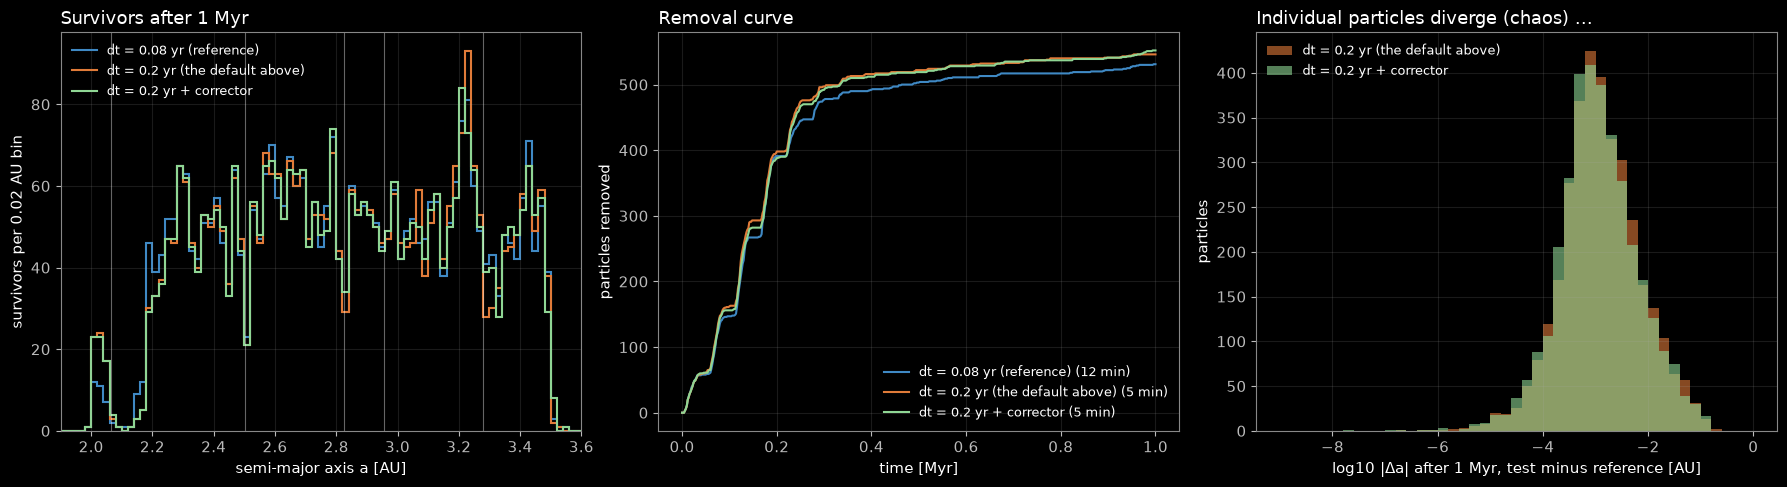

In [5]:
STEP_TESTS = [("kirkwood_gaps_sim_1Myr_dt0.08.npz", 0.08, 0, "dt = 0.08 yr (reference)"),
              ("kirkwood_gaps_sim_1Myr_dt0.2.npz", 0.2, 0, "dt = 0.2 yr (the default above)"),
              ("kirkwood_gaps_sim_1Myr_dt0.2_corr.npz", 0.2, 11, "dt = 0.2 yr + corrector")]
tests = {}
for path, dt, corrector, label in STEP_TESTS:
    if os.path.exists(path):
        d = np.load(path)
        tests[label] = (d["times"], d["a"], d["e"], float(d["minutes"]) if "minutes" in d else np.nan)
    else:
        tic = time.time()
        t_, a_, e_ = run_parallel(1, 0.0, 1.0e6, 2000.0, dt=dt, corrector=corrector, ckpt=None)
        minutes = (time.time() - tic) / 60
        np.savez_compressed(path, times=t_, a=a_, e=e_, dt=dt, corrector=corrector, minutes=minutes)
        tests[label] = (t_, a_, e_, minutes)
    print(f"{label:<28} {tests[label][3]:5.1f} min")

def removed_mask(a_, e_):
    # removed from the first snapshot at which q < Q_MARS (or, in runs that delete particles, the first NaN)
    return np.cumsum((a_ * (1 - e_) < Q_MARS) | ~np.isfinite(a_), axis=0) > 0

ref_label = STEP_TESTS[0][3]
t_ref, a_ref, e_ref, _ = tests[ref_label]
rem_ref = removed_mask(a_ref, e_ref)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = {ref_label: BLUE, STEP_TESTS[1][3]: ORANGE, STEP_TESTS[2][3]: "#8fd694"}
for label, (t_, a_, e_, minutes) in tests.items():
    rem = removed_mask(a_, e_)
    axes[0].stairs(np.histogram(a_[-1][~rem[-1]], bins=BINS)[0], BINS, color=colors[label], lw=1.5, label=label)
    axes[1].plot(t_ / 1e6, rem.sum(axis=1), color=colors[label], lw=1.5, label=f"{label} ({minutes:.0f} min)")
    if label != ref_label:
        both = ~rem[-1] & ~rem_ref[-1]
        da = np.abs(a_[-1] - a_ref[-1])[both]
        axes[2].hist(np.log10(np.maximum(da, 1e-9)), bins=np.linspace(-9, 0, 46), color=colors[label], alpha=0.6, lw=0, label=label)
        same = np.mean(rem[-1] == rem_ref[-1])
        print(f"{label}: same removal verdict as the reference for {100 * same:.1f}% of particles; "
              f"median |da| after 1 Myr among survivors {np.median(da):.1e} AU")
for name, a_r in a_res.items():
    axes[0].axvline(a_r, color="white", lw=0.8, alpha=0.4)
axes[0].set_xlim(1.9, 3.6); axes[0].set_xlabel("semi-major axis a [AU]"); axes[0].set_ylabel("survivors per 0.02 AU bin")
axes[0].set_title("Survivors after 1 Myr", loc="left"); axes[0].legend(framealpha=0, fontsize=9)
axes[1].set_xlabel("time [Myr]"); axes[1].set_ylabel("particles removed"); axes[1].set_title("Removal curve", loc="left")
axes[1].legend(framealpha=0, fontsize=9, loc="lower right")
axes[2].set_xlabel("log10 |Δa| after 1 Myr, test minus reference [AU]"); axes[2].set_ylabel("particles")
axes[2].set_title("Individual particles diverge (chaos) ...", loc="left"); axes[2].legend(framealpha=0, fontsize=9)
for ax in axes:
    ax.grid(alpha=0.15)
plt.tight_layout(); plt.show()

# Step 4: Removing the Planet-Crossers

The simulation contains only the Sun, Jupiter and Saturn, so a particle whose eccentricity has been pumped up merely *crosses* the inner planets' orbits; nothing ever removes it. In the real Solar System a Mars-crossing asteroid is scattered within a few million to a few tens of millions of years, and an Earth-crosser within a few million ([Gladman et al. 1997](https://ui.adsabs.harvard.edu/abs/1997Sci...277..197G)). We stand in for that step with a simple rule: a particle counts as **removed from the belt** from the first snapshot at which its perihelion `q = a (1 − e)` falls inside Mars's aphelion distance, 1.67 AU, and in the plots it stays frozen, in grey, at the point where that happened. This compresses the real removal step to zero time, which is why the gaps here open faster than they would in nature — but the *pattern* of what is removed, and where, is the physics we are after.

The two panels below show the belt at the start and at the end of the run in the (a, e) plane, with the resonances marked and the Mars-crossing line drawn. Then the histogram of survivors is compared with the real belt.

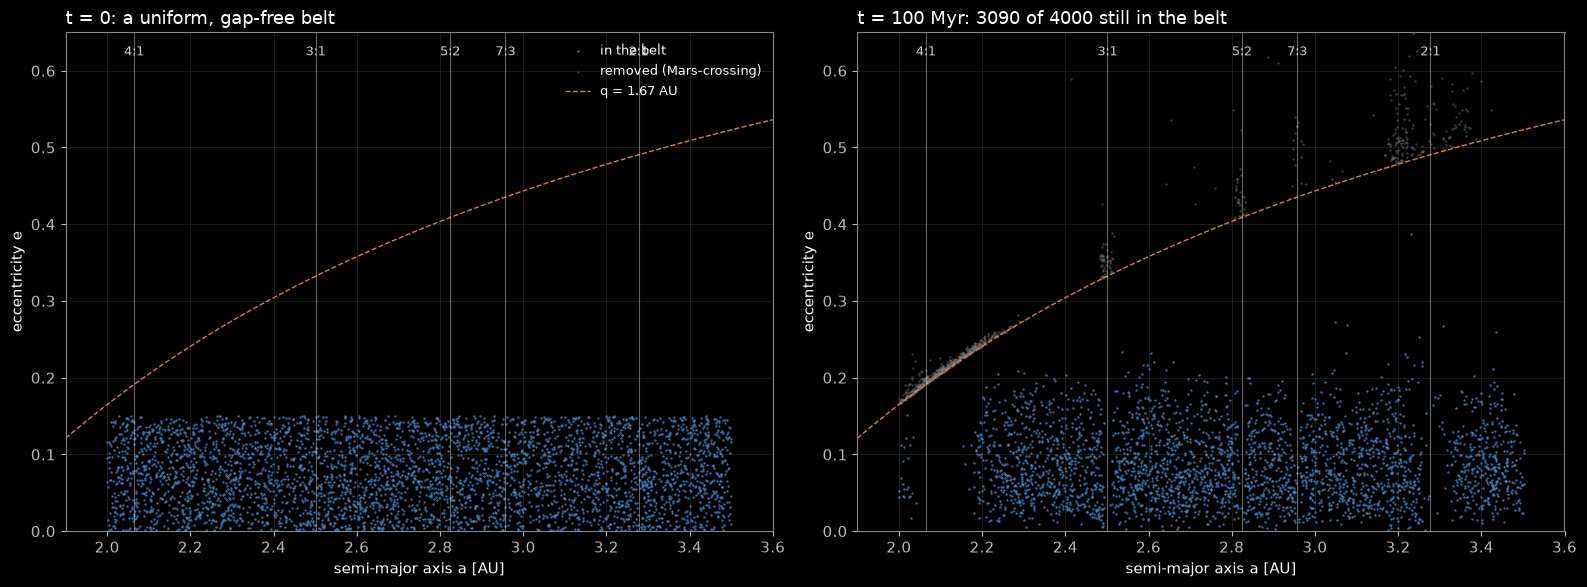

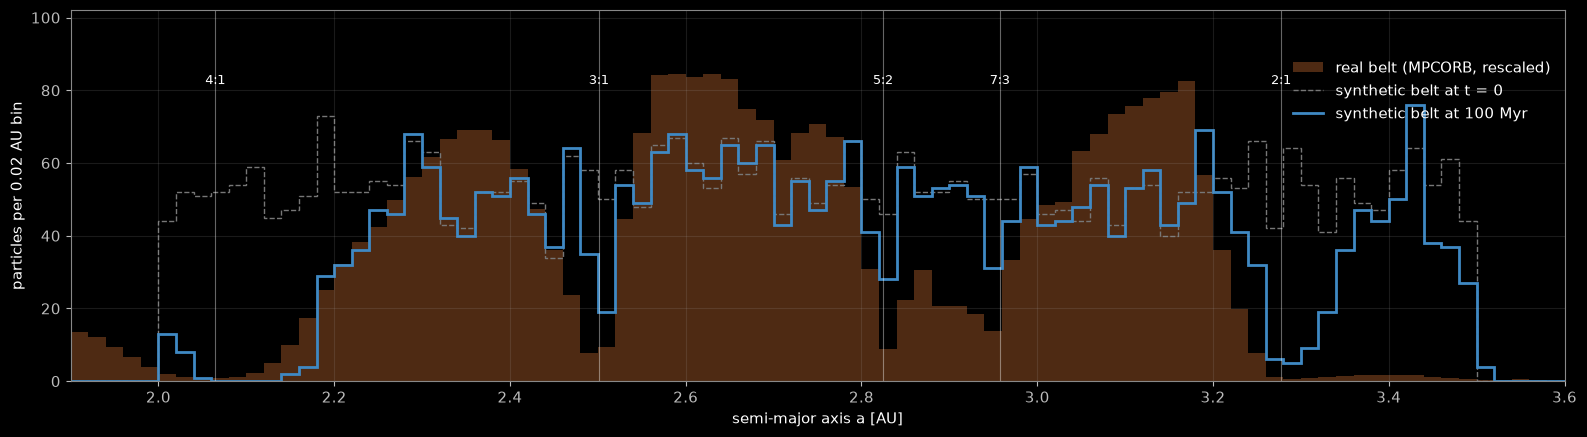

In [6]:
crossed = removed_mask(a_sim, e_sim)              # True from the Mars-crossing snapshot onward
alive = ~crossed
n_alive = alive.sum(axis=1)

# For plotting, freeze each removed particle at its last recorded state -- the snapshot where it crossed.
last_valid = np.maximum.accumulate(np.where(np.isfinite(a_sim), np.arange(len(times))[:, None], 0), axis=0)
a_plot, e_plot = np.take_along_axis(a_sim, last_valid, axis=0), np.take_along_axis(e_sim, last_valid, axis=0)

def survivor_hist(j):
    return np.histogram(a_plot[j][alive[j]], bins=BINS)[0]
hist_real = np.histogram(a_real, bins=BINS)[0]
scale = survivor_hist(0).mean() / hist_real[(BINS[:-1] > 2.1) & (BINS[:-1] < 3.3)].mean()


def draw_ae_axes(ax, j, title):
    ax.scatter(a_plot[j][alive[j]], e_plot[j][alive[j]], s=3, color=BLUE, alpha=0.8, lw=0, label="in the belt")
    ax.scatter(a_plot[j][crossed[j]], e_plot[j][crossed[j]], s=3, color=GREY, alpha=0.5, lw=0, label="removed (Mars-crossing)")
    a_line = np.linspace(1.9, 3.6, 200)
    ax.plot(a_line, 1 - Q_MARS / a_line, color=ORANGE, lw=1, ls="--", label=f"q = {Q_MARS} AU")
    for name, a_r in a_res.items():
        ax.axvline(a_r, color="white", lw=0.8, alpha=0.4)
        ax.text(a_r, 0.62, name, ha="center", fontsize=9, color="white", alpha=0.8)
    ax.set_xlim(1.9, 3.6); ax.set_ylim(0, 0.65)
    ax.set_xlabel("semi-major axis a [AU]"); ax.set_ylabel("eccentricity e")
    ax.set_title(title, loc="left"); ax.grid(alpha=0.15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
draw_ae_axes(axes[0], 0, "t = 0: a uniform, gap-free belt")
draw_ae_axes(axes[1], len(times) - 1, f"t = {times[-1]/1e6:.0f} Myr: {n_alive[-1]} of {a_sim.shape[1]} still in the belt")
axes[0].legend(loc="upper right", framealpha=0, fontsize=9)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(16, 4.5))
ax.stairs(hist_real * scale, BINS, fill=True, color=ORANGE, alpha=0.35, label="real belt (MPCORB, rescaled)")
ax.stairs(survivor_hist(0), BINS, color=GREY, lw=1, ls="--", label="synthetic belt at t = 0")
ax.stairs(survivor_hist(len(times) - 1), BINS, color=BLUE, lw=2, label=f"synthetic belt at {times[-1]/1e6:.0f} Myr")
for name, a_r in a_res.items():
    ax.axvline(a_r, color="white", lw=0.8, alpha=0.4); ax.text(a_r, ax.get_ylim()[1] * 0.95, name, ha="center", fontsize=9, va="top")
ax.set_xlim(1.9, 3.6); ax.set_ylim(0, ax.get_ylim()[1] * 1.15); ax.set_xlabel("semi-major axis a [AU]"); ax.set_ylabel("particles per 0.02 AU bin")
ax.legend(loc="upper right", bbox_to_anchor=(1.0, 0.9), framealpha=0); ax.grid(alpha=0.15); plt.tight_layout(); plt.show()

### Reading the figures

In the (a, e) plane the resonances have become vertical plumes: particles at the 3:1, 5:2, 7:3 and 2:1 locations have had their eccentricities pumped upward, and the ones that reached the dashed Mars-crossing line are greyed out. Away from the resonances nothing has happened — eccentricities have drifted a little under the planets' secular perturbations, but essentially no particle has left (a control region between the resonances loses a fraction of a percent). Near the inner edge, below about 2.1 AU, a broad band has been cleared almost completely: that is the **ν₆ secular resonance**, where an asteroid's perihelion precesses at the same rate as Saturn's, which pumps eccentricity just as effectively as a mean-motion resonance and is what defines the belt's inner boundary.

In the histogram all five gaps have opened where the real belt has them, and the inner edge has moved outward to the real one. The timescales are the interesting part, and the animation makes them visible. Counting the particles that started within 0.015 AU of each resonance:

| Removed from the core of ... | 1 Myr | 10 Myr | 30 Myr | 100 Myr |
|---|---|---|---|---|
| inner edge (a < 2.1 AU, ν₆ and 4:1) | 73% | 85% | 89% | 91% |
| 3:1 | 49% | 57% | 64% | 67% |
| 5:2 | 32% | 38% | 41% | 45% |
| 7:3 | 3% | 24% | 31% | 35% |
| 2:1 | 1% | 36% | 65% | 91% |
| beyond 3.3 AU (the outer edge) | 1% | 15% | 19% | 25% |
| control regions between resonances | 0% | 0% | 0.3% | 0.8% |

The 3:1 and 5:2 cores empty within the first million years and then only creep — what is left inside those windows lies outside the chaotic zone and is genuinely stable. The 7:3 needs ten million years to get going. And the 2:1 does *nothing* for about three million years, then empties steadily for the rest of the run: by a hundred million years it is the most thoroughly cleared of all the gaps, and the region beyond it, where the real belt ends, has begun to thin too. That ordering is real. The inner resonances are cleared by Wisdom's fast chaotic pumping; the 2:1 works through a slower interplay of secondary and secular resonances inside it, and contains long-lived islands — the Zhongguo and Griqua groups are real asteroids living there today — so it empties on timescales of tens to hundreds of millions of years ([Moons, Morbidelli & Migliorini 1998](https://ui.adsabs.harvard.edu/abs/1998Icar..135..458M); [Gladman et al. 1997](https://ui.adsabs.harvard.edu/abs/1997Sci...277..197G) found the same hierarchy of lifetimes with injected particles). Between the resonances nothing happens at all: less than one particle in a hundred leaves in a hundred million years. The remaining differences from the real belt — the 7:3 still shallow, the outer edge only half formed, the real belt's smooth decline between 2.5 and 3.3 AU — are the work of the following few billion years and of processes not in this model, above all the Yarkovsky drift that slowly feeds small asteroids into the resonances.

# Step 5: The Animation

Now the same two views as a movie, with a **time-warped clock**: one frame for every fourth snapshot, so the clock runs at 8,000 years per frame through the first million years, 80,000 through the next nine million, and 800,000 through the last ninety million — a hundred million years in about thirty seconds, with the clock speed shown on screen. The left panel is the (a, e) plane — watch the resonant plumes rise and their tops turn grey as particles cross the Mars line, the inner ones first and the 2:1 only once the clock has sped up — and the right panel is the histogram of survivors with the real belt underneath. The pattern is the one from the minimoon animation tutorial: create every artist once, update them in `draw`, and save with `FFMpegWriter` and `PillowWriter`. (A scatter of thousands of moving points compresses poorly, so this video uses a lower frame rate and a higher compression setting than the minimoon ones; even so it is the largest file in the tutorial series.)

Two small tricks are specific to this animation. A scatter plot's points are moved with `set_offsets` and recoloured with `set_facecolors`, so a single scatter artist serves for both the surviving and the removed particles; and the histogram is a `stairs` artist whose heights are replaced with `set_data`, which is far cheaper than redrawing bars.

In [7]:
def make_kirkwood_animation(fps=12, every=4):
    frames = np.arange(0, len(times), every)                 # every fourth snapshot: ~30 s at 12 fps
    colors = np.empty((a_sim.shape[1], 4))
    fig = plt.figure(figsize=(14.4, 6.4), dpi=100)
    gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.1], wspace=0.2, left=0.05, right=0.98, top=0.85, bottom=0.13)
    ax, ax2 = fig.add_subplot(gs[0]), fig.add_subplot(gs[1])
    fig.suptitle("How the Kirkwood gaps form: a gap-free belt under Jupiter and Saturn", fontsize=16, fontweight="bold", y=0.96)
    fig.text(0.05, 0.895, f"{a_sim.shape[1]} test particles, REBOUND WHFast; particles are removed once they cross Mars's orbit (q < {Q_MARS} AU)",
             fontsize=10, color="#bbbbbb")

    # left: (a, e) plane
    scat = ax.scatter(a_plot[0], e_plot[0], s=3, lw=0)
    a_line = np.linspace(1.9, 3.6, 200)
    ax.plot(a_line, 1 - Q_MARS / a_line, color=ORANGE, lw=1, ls="--")
    ax.text(3.55, 1 - Q_MARS / 3.55 + 0.02, "Mars-crossing", ha="right", color=ORANGE, fontsize=9)
    for name, a_r in a_res.items():
        ax.axvline(a_r, color="white", lw=0.8, alpha=0.4); ax.text(a_r, 0.62, name, ha="center", fontsize=9, alpha=0.8)
    ax.set_xlim(1.9, 3.6); ax.set_ylim(0, 0.65); ax.grid(alpha=0.15)
    ax.set_xlabel("semi-major axis a [AU]"); ax.set_ylabel("eccentricity e")
    time_txt = ax.text(0.02, 0.95, "", transform=ax.transAxes, fontsize=15, fontweight="bold", va="top")
    count_txt = ax.text(0.02, 0.87, "", transform=ax.transAxes, fontsize=11, va="top", color="#bbbbbb")
    clock_txt = ax.text(0.02, 0.81, "", transform=ax.transAxes, fontsize=10, va="top", color="#bbbbbb")

    # right: histogram of survivors against the real belt
    ax2.stairs(hist_real * scale, BINS, fill=True, color=ORANGE, alpha=0.35, label="real belt (MPCORB, rescaled)")
    hist_artist = ax2.stairs(survivor_hist(0), BINS, color=BLUE, lw=2, label="synthetic belt, survivors")
    ymax = survivor_hist(0).max() * 1.6
    for name, a_r in a_res.items():
        ax2.axvline(a_r, color="white", lw=0.8, alpha=0.4); ax2.text(a_r, ymax * 0.97, name, ha="center", fontsize=9, va="top")
    ax2.set_xlim(1.9, 3.6); ax2.set_ylim(0, ymax); ax2.grid(alpha=0.15)
    ax2.set_xlabel("semi-major axis a [AU]"); ax2.set_ylabel("particles per 0.02 AU bin")
    ax2.legend(loc="upper right", bbox_to_anchor=(1.0, 0.9), framealpha=0, fontsize=9)

    def draw(k):
        j = frames[k]
        scat.set_offsets(np.column_stack([a_plot[j], e_plot[j]]))
        colors[alive[j]] = (0.247, 0.537, 0.769, 0.85)           # BLUE
        colors[crossed[j]] = (0.47, 0.47, 0.47, 0.35)            # GREY
        scat.set_facecolors(colors)
        hist_artist.set_data(survivor_hist(j))
        time_txt.set_text(f"t = {times[j]/1e6:6.2f} Myr")
        count_txt.set_text(f"{n_alive[j]} in the belt, {a_sim.shape[1] - n_alive[j]} removed")
        clock_txt.set_text(f"clock: {every * cadence_of[j]:,.0f} yr per frame")
        return scat, hist_artist, time_txt, count_txt, clock_txt

    return fig, FuncAnimation(fig, draw, frames=len(frames), interval=1000 / fps, blit=False)

OUT_DIR = Path("../animations")
OUT_DIR.mkdir(parents=True, exist_ok=True)

def save_animation(fig, anim, stem, fps=12, gif_fps=8, gif_dpi=45):
    stem = OUT_DIR / stem
    tic = time.time()
    anim.save(f"{stem}.mp4", writer=FFMpegWriter(fps=fps, codec="h264", bitrate=-1,
                                                 extra_args=["-pix_fmt", "yuv420p", "-crf", "29"]), dpi=100)
    anim.save(f"{stem}.gif", writer=PillowWriter(fps=gif_fps), dpi=gif_dpi)
    fig.savefig(f"{stem}.png", dpi=100)
    sizes = {ext: os.path.getsize(f"{stem}.{ext}") / 1e6 for ext in ("mp4", "gif", "png")}
    print(f"{stem.name}: mp4 {sizes['mp4']:.1f} MB, gif {sizes['gif']:.1f} MB, png {sizes['png']:.2f} MB ({time.time() - tic:.0f} s)")
    return stem

def show_video(stem, width=960):
    data = base64.b64encode(Path(f"{stem}.mp4").read_bytes()).decode()
    return HTML(f'<video controls loop muted playsinline width="{width}" src="data:video/mp4;base64,{data}"></video>')

fig, anim = make_kirkwood_animation()
stem = save_animation(fig, anim, "kirkwood_gaps_forming")
plt.close(fig)
show_video(stem)

kirkwood_gaps_forming: mp4 3.9 MB, gif 7.7 MB, png 0.17 MB (115 s)


# Summary

In this tutorial we:

1. **Took the real belt's** semi-major-axis distribution from `MPCORB.DAT` as the target, with the resonance locations from Jupiter's orbit
2. **Built a gap-free synthetic belt** of test particles, uniform in semi-major axis with small eccentricities and inclinations
3. **Integrated it for ten million years** with REBOUND's `WHFast`, using `N_active` for test particles, `safe_mode = 0` for speed, a vectorized element readout, and `multiprocessing` to spread the particles over the CPU cores — and checked, by rerunning a million years at two step sizes, that the coarse 0.2-year step reproduces the population statistics even though chaos means it cannot reproduce individual particles
4. **Removed Mars-crossers** as a stand-in for planetary encounters, and saw resonant eccentricity pumping — Wisdom's mechanism — carve the 3:1 and 5:2 gaps and the ν₆ inner edge within the first million years, the 7:3 over ten million, and the 2:1 over a hundred million, with the outer edge of the belt beginning to form at the end
5. **Animated** the (a, e) plane and the histogram together with a time-warped clock, and rendered the result as MP4, GIF and a poster frame for the [animations page](https://docs.minorplanetcenter.net/tutorials/animation_tutorials/)

### Ideas to extend

- Add a fourth phase to a billion years (about three days on eight cores) and watch the 7:3 finish and the outer edge form; the checkpoints make it a one-line change
- Add Mars and Earth as massive bodies (with a smaller time step) and let REBOUND remove particles on real close encounters instead of the `q < 1.67 AU` rule
- Colour the particles by their *initial* semi-major axis to see how far the resonant ones wander before they leave
- Add the top-down "normalized belt" map from the Kirkwood tutorial as a third panel

### Further Resources

- [Wisdom (1983), *Chaotic behavior and the origin of the 3/1 Kirkwood gap*, Icarus 56, 51](https://ui.adsabs.harvard.edu/abs/1983Icar...56...51W)
- [Gladman et al. (1997), *Dynamical lifetimes of objects injected into asteroid belt resonances*, Science 277, 197](https://ui.adsabs.harvard.edu/abs/1997Sci...277..197G)
- [Moons, Morbidelli & Migliorini (1998), *Dynamical structure of the 2/1 commensurability with Jupiter and the origin of the resonant asteroids*, Icarus 135, 458](https://ui.adsabs.harvard.edu/abs/1998Icar..135..458M)
- [Rein & Tamayo (2015), *WHFast: a fast and unbiased implementation of a symplectic Wisdom-Holman integrator*, MNRAS 452, 376](https://ui.adsabs.harvard.edu/abs/2015MNRAS.452..376R)
- [REBOUND documentation: WHFast and test particles](https://rebound.readthedocs.io/)
- [Companion tutorial: The Kirkwood Gaps](https://docs.minorplanetcenter.net/tutorials/notebooks/mpc_tutorial_orbit_kirkwood/)
- [Companion tutorial: From MPC Orbit to N-Body Simulation](https://docs.minorplanetcenter.net/tutorials/notebooks/mpc_tutorial_orbit_to_rebound/)
- [Companion tutorial: Animating Minimoons](https://docs.minorplanetcenter.net/tutorials/notebooks/mpc_tutorial_orbit_animation_minimoons/)
- [Working with Orbits](https://docs.minorplanetcenter.net/tutorials/orbit_tutorials/): the static tutorials this notebook builds on

For questions or feedback, contact the MPC via the [Jira Helpdesk](https://mpc-service.atlassian.net/servicedesk/customer/portal/13/create/148).